In [26]:
import pandas as pd
df = pd.read_csv("AIR_HOUR_2021.csv", encoding="euc-kr")
df[:5]

,측정일시,측정소 코드,측정항목 코드,평균값,측정기 상태,국가 기준초과 구분,지자체 기준초과 구분,저장일시
0,20211231230000,108,5,0.700,0,0,0,20220101000024
1,20211231230000,108,6,0.018,0,0,0,20220101000024
2,20211231230000,108,8,19.000,0,0,0,20220101000024
3,20211231230000,108,9,8.000,0,0,0,20220101000024
4,20211231230000,103,3,0.018,0,0,0,20220101000025


In [27]:
#df.describe()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1314000 entries, 0 to 1313999
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   측정일시         1314000 non-null  int64  
 1   측정소 코드       1314000 non-null  int64  
 2   측정항목 코드      1314000 non-null  int64  
 3   평균값          1314000 non-null  float64
 4   측정기 상태       1314000 non-null  int64  
 5   국가 기준초과 구분   1314000 non-null  int64  
 6   지자체 기준초과 구분  1314000 non-null  int64  
 7   저장일시         1314000 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 80.2 MB


In [29]:
len(df['측정일시'].unique())

8760

In [30]:
len(df['측정소 코드'].unique())

25

In [31]:
len(df['측정항목 코드'].unique())

6

In [32]:
df_normal = df[df["측정기 상태"] == 0]
df_normal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1288259 entries, 0 to 1313999
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   측정일시         1288259 non-null  int64  
 1   측정소 코드       1288259 non-null  int64  
 2   측정항목 코드      1288259 non-null  int64  
 3   평균값          1288259 non-null  float64
 4   측정기 상태       1288259 non-null  int64  
 5   국가 기준초과 구분   1288259 non-null  int64  
 6   지자체 기준초과 구분  1288259 non-null  int64  
 7   저장일시         1288259 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 88.5 MB


In [33]:
1288259 / 1314000 

0.980410197869102

In [34]:
df_normal[:2]

,측정일시,측정소 코드,측정항목 코드,평균값,측정기 상태,국가 기준초과 구분,지자체 기준초과 구분,저장일시
0,20211231230000,108,5,0.700,0,0,0,20220101000024
1,20211231230000,108,6,0.018,0,0,0,20220101000024


In [35]:
df_pm = df_normal[df_normal["측정항목 코드"].isin([8, 9])]
df_pm[:2]

,측정일시,측정소 코드,측정항목 코드,평균값,측정기 상태,국가 기준초과 구분,지자체 기준초과 구분,저장일시
2,20211231230000,108,8,19.0,0,0,0,20220101000024
3,20211231230000,108,9,8.0,0,0,0,20220101000024


In [36]:
df_pm = df_pm.drop(columns=["저장일시","측정소 코드","측정기 상태", "국가 기준초과 구분", "지자체 기준초과 구분"])
df_pm[:2]

,측정일시,측정항목 코드,평균값
2,20211231230000,8,19.0
3,20211231230000,9,8.0


In [37]:
df_result = df_pm.pivot_table(index="측정일시", columns="측정항목 코드", values="평균값", aggfunc="first").reset_index()
df_result[:5]

측정항목 코드,측정일시,8,9
0,20210101000000,18.0,15.0
1,20210101010000,21.0,12.0
2,20210101020000,29.0,19.0
3,20210101030000,12.0,12.0
4,20210101040000,24.0,14.0


In [38]:
df_result = df_result.rename(columns={8:"pm10", 9:"pm2.5"})
df_result[:2]

측정항목 코드,측정일시,pm10,pm2.5
0,20210101000000,18.0,15.0
1,20210101010000,21.0,12.0


In [39]:
df_result["측정일시"] = df_result["측정일시"].astype(str)
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   측정일시    8760 non-null   object 
 1   pm10    8760 non-null   float64
 2   pm2.5   8760 non-null   float64
dtypes: float64(2), object(1)
memory usage: 205.4+ KB


In [40]:
df_result["날짜"] = pd.to_datetime(df_result["측정일시"].str[:8], format="%Y%m%d").dt.date
df_result["시간"] = pd.to_datetime(df_result["측정일시"].str[8:], format="%H%M%S").dt.time
df_result[:2]


# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# # --- 3. 데이터 기본 정보 확인 및 전처리 ---
# print("\n[데이터 상위 5개 행 미리보기]")
# print(df_result.head())

# print("\n[데이터 기본 정보]")
# df_result.info()

# # '측정일시' 컬럼을 문자열(object)에서 날짜/시간(datetime) 타입으로 변환합니다.
# # 이렇게 해야 시간 순서대로 정렬하거나 특정 기간의 데이터를 쉽게 추출할 수 있습니다.
# if '측정일시' in df_result.columns:
#     df_result['측정일시'] = pd.to_datetime(df_result['측정일시'])
#     print("\n'측정일시' 컬럼을 datetime 타입으로 변환했습니다.")

# # 결측치(비어있는 값)가 있는지 확인합니다.
# print("\n[컬럼별 결측치 개수]")
# print(df_result.isnull().sum())

# # --- 4. 데이터 시각화를 통한 통계 분석 ---

# # 4-1. 시간에 따른 미세먼지/초미세먼지 농도 변화
# plt.figure(figsize=(12, 6))
# sns.lineplot(data=df_result, x='측정일시', y='pm10', label='pm10')
# sns.lineplot(data=df_result, x='측정일시', y='pm2.5', label='pm2.5')
# plt.title('시간에 따른 미세먼지 농도 변화 추이')
# plt.xlabel('측정일시')
# plt.ylabel('농도 (µg/m³)')
# plt.grid(True)
# plt.legend()
# plt.show()


# # 4-2. 지역별 평균 미세먼지 농도 비교
# if '지역' in df_result.columns:
#     plt.figure(figsize=(10, 6))
#     # 지역별로 그룹화하여 평균 미세먼지 농도를 계산합니다.
#     avg_by_region = df_result.groupby('지역')['pm10'].mean().sort_values(ascending=False)
    
#     sns.barplot(x=avg_by_region.index, y=avg_by_region.values)
#     plt.title('지역별 평균 미세먼지(PM10) 농도 비교')
#     plt.xlabel('지역')
#     plt.ylabel('평균 농도 (µg/m³)')
#     plt.show()

# AI 추천 시각화끝

측정항목 코드,측정일시,pm10,pm2.5,날짜,시간
0,20210101000000,18.0,15.0,2021-01-01,00:00:00
1,20210101010000,21.0,12.0,2021-01-01,01:00:00


In [41]:
df_result = df_result.drop(columns=["측정일시"])
df_result[:2]


측정항목 코드,pm10,pm2.5,날짜,시간
0,18.0,15.0,2021-01-01,00:00:00
1,21.0,12.0,2021-01-01,01:00:00


In [42]:
daily_avg = df_result.groupby("날짜")[["pm10", "pm2.5"]].mean().reset_index()
daily_avg[:5]

측정항목 코드,날짜,pm10,pm2.5
0,2021-01-01,25.833333,16.500000
1,2021-01-02,34.083333,10.958333
2,2021-01-03,35.625000,13.166667
3,2021-01-04,38.916667,21.291667
4,2021-01-05,24.916667,14.583333


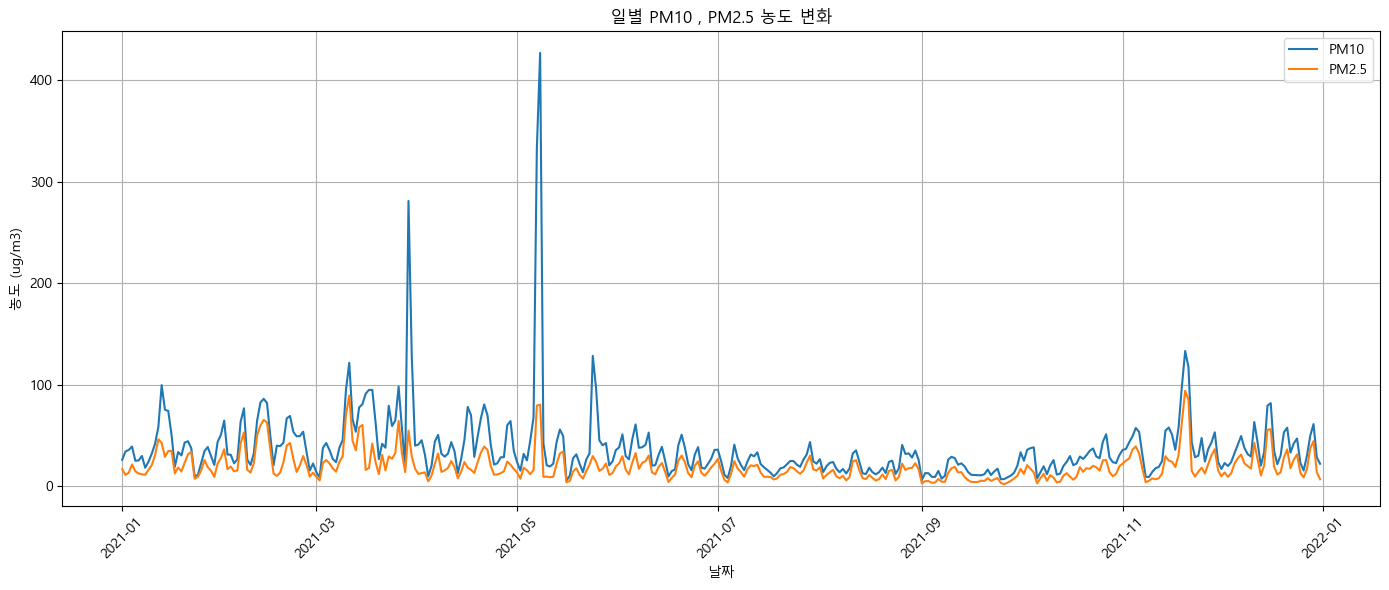

In [43]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic' #Window: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False    # - dash 깨짐 방지

plt.figure(figsize=(14, 6))
plt.plot(daily_avg["날짜"], daily_avg["pm10"], label="PM10")
plt.plot(daily_avg["날짜"], daily_avg["pm2.5"], label="PM2.5")
plt.xlabel("날짜")
plt.ylabel("농도 (ug/m3)")
plt.title("일별 PM10 , PM2.5 농도 변화")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

PM10과 PM2.5의 상관 계수: 0.75


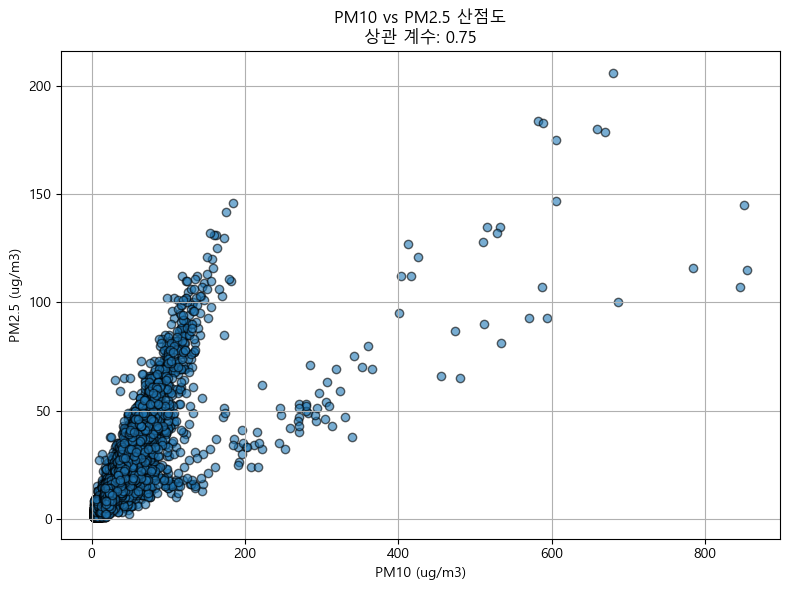

In [44]:
correlation = df_result[["pm10", "pm2.5"]].corr().iloc[0,1]
print(f"PM10과 PM2.5의 상관 계수: {correlation:.2f}")

plt.figure(figsize=(8,6))
plt.scatter(df_result["pm10"], df_result["pm2.5"], alpha=0.6, edgecolors='k')
plt.xlabel("PM10 (ug/m3)")
plt.ylabel("PM2.5 (ug/m3)")
plt.title(f"PM10 vs PM2.5 산점도\n상관 계수: {correlation:.2f}")
plt.grid()
plt.tight_layout()
plt.show()

PM10과 PM2.5의 상관 계수: 0.64


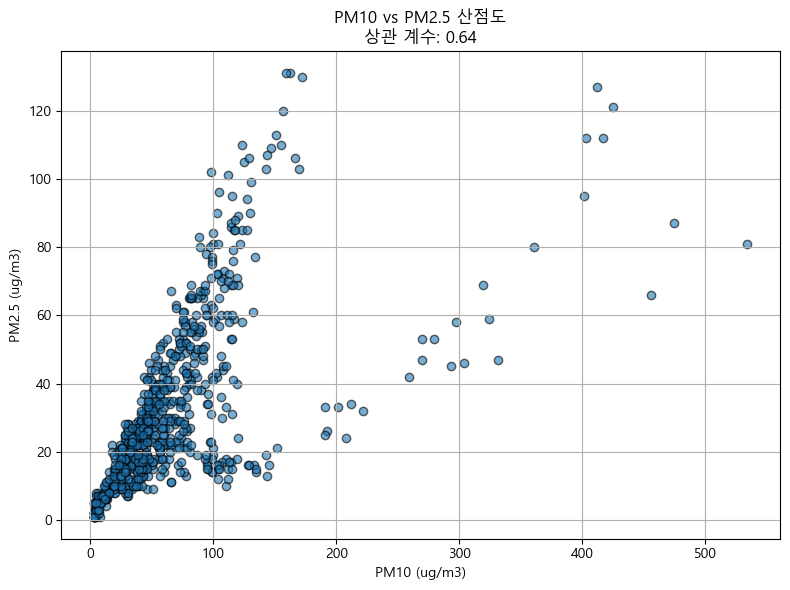

In [45]:
# start_date = '2021-03-01'
# end_date = '2021-03-31'
from datetime import date
start_date = date(2021, 3, 1)
end_date = date(2021, 3, 31)
# start_date = pd.to_datetime('2021-03-01')
# end_date = pd.to_datetime('2021-03-31')
# print(df_result.info())
mask = (df_result["날짜"] >= start_date) & (df_result["날짜"] <= end_date)
# mask = df_result["날짜"].between(start_date, end_date)

# df_filter = df_result.loc(mask)
df_filter = df_result.loc[mask]

correlation = df_filter[["pm10", "pm2.5"]].corr().iloc[0,1]
print(f"PM10과 PM2.5의 상관 계수: {correlation:.2f}")

plt.figure(figsize=(8,6))
plt.scatter(df_filter["pm10"], df_filter["pm2.5"], alpha=0.6, edgecolors='k')
plt.xlabel("PM10 (ug/m3)")
plt.ylabel("PM2.5 (ug/m3)")
plt.title(f"PM10 vs PM2.5 산점도\n상관 계수: {correlation:.2f}")
plt.grid()
plt.tight_layout()
plt.show()

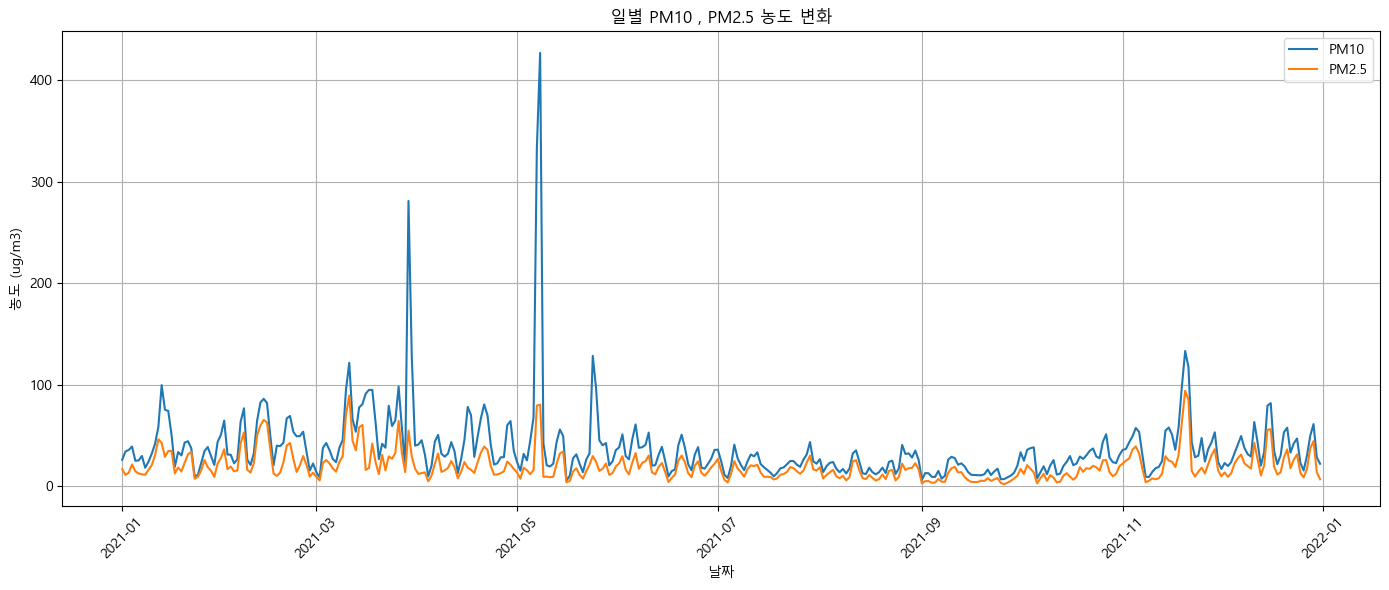

In [46]:
plt.rcParams['font.family'] = 'Malgun Gothic' #Window: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False    # - dash 깨짐 방지

plt.figure(figsize=(14, 6))
plt.plot(daily_avg["날짜"], daily_avg["pm10"], label="PM10")
plt.plot(daily_avg["날짜"], daily_avg["pm2.5"], label="PM2.5")
plt.xlabel("날짜")
plt.ylabel("농도 (ug/m3)")
plt.title("일별 PM10 , PM2.5 농도 변화")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

예측 결과: 
Linear -> pm10 = 300 일때, pm2.5의 예측값: 96.13
Ridge -> pm10 = 300 일때, pm2.5의 예측값: 96.13
Forest -> pm10 = 300 일때, pm2.5의 예측값: 57.23


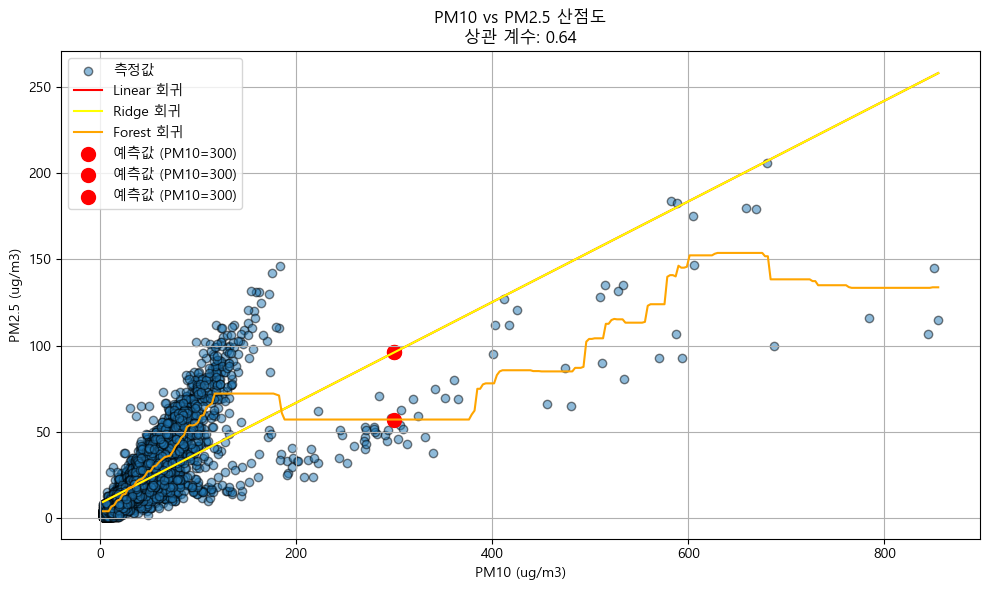

In [47]:
# ML 분석
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Na제거(null)
na_filtered = df_result[["pm10", "pm2.5"]].dropna()

X = na_filtered["pm10"].values.reshape(-1, 1)
y = na_filtered["pm2.5"].values

# 300: 예측용 입력
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

models = {
    "Linear" : LinearRegression(),
    "Ridge" : Ridge(alpha=1.0),
    "Forest" : RandomForestRegressor(max_depth=4)
}

predictions = {}
for name, model in models.items():
    model.fit(X, y)
    predictions[name] = model.predict(X_range)

myInput = 300
pm10_input = np.array([[myInput]])
print("예측 결과: ")
for name, model in models.items():
    pm25_pred = model.predict(pm10_input)[0]
    print(f"{name} -> pm10 = {myInput} 일때, pm2.5의 예측값: {pm25_pred:.2f}")

plt.figure(figsize=(10,6))
# data
plt.scatter(X, y, alpha=0.5, edgecolors='k', label="측정값")
# 회귀선(ML 추정)
colors = {"Linear":"red", "Ridge":"yellow", "Forest":"orange"}
for name, y_pred in predictions.items():
    plt.plot(X_range, y_pred, label=f"{name} 회귀", color=colors[name])
# myInput
plt.scatter(myInput, models["Linear"].predict(pm10_input)[0], color="red", s=100, 
            label=f"예측값 (PM10={myInput})")
plt.scatter(myInput, models["Ridge"].predict(pm10_input)[0], color="red", s=100, 
            label=f"예측값 (PM10={myInput})")
plt.scatter(myInput, models["Forest"].predict(pm10_input)[0], color="red", s=100, 
            label=f"예측값 (PM10={myInput})")

plt.xlabel("PM10 (ug/m3)")
plt.ylabel("PM2.5 (ug/m3)")
plt.title(f"PM10 vs PM2.5 산점도\n상관 계수: {correlation:.2f}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()